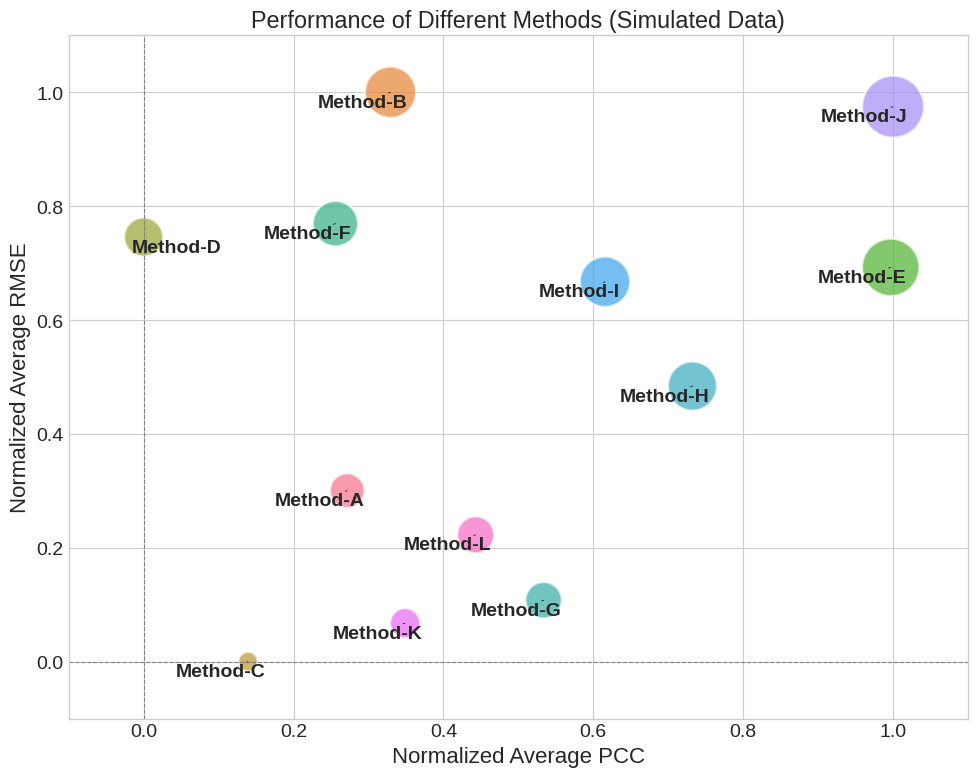

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

# --- 1. 模拟数据生成（不依赖于本地文件）---
# 假设有12个不同的方法，类似于您的SMILES编码器
Smiles_enc = [
    'Method-A', 'Method-B', 'Method-C', 'Method-D', 'Method-E', 'Method-F',
    'Method-G', 'Method-H', 'Method-I', 'Method-J', 'Method-K', 'Method-L'
]

# 模拟每个方法的性能数据
# PCC值越高越好，RMSE值越低越好
# 我们使用正态分布来模拟真实数据
pcc_data = np.random.uniform(0.6, 0.9, size=len(Smiles_enc))
rmse_data = np.random.uniform(0.1, 0.3, size=len(Smiles_enc))

# 创建一个DataFrame来存储模拟数据
df_raw = pd.DataFrame({
    'Method': Smiles_enc,
    'PCC': pcc_data,
    'RMSE': rmse_data
})

# --- 2. 数据归一化处理 ---
# PCC 越高越好，所以归一化公式是 (x - min) / (max - min)
pcc_min, pcc_max = df_raw['PCC'].min(), df_raw['PCC'].max()
df_raw['Normalized_PCC'] = (df_raw['PCC'] - pcc_min) / (pcc_max - pcc_min)

# RMSE 越小越好，所以归一化公式是 1 - (x - min) / (max - min)
rmse_min, rmse_max = df_raw['RMSE'].min(), df_raw['RMSE'].max()
df_raw['Normalized_RMSE'] = 1 - (df_raw['RMSE'] - rmse_min) / (rmse_max - rmse_min)

# 计算综合得分，用于控制气泡大小（越大越好）
df_raw['Performance_Score'] = (df_raw['Normalized_PCC'] + df_raw['Normalized_RMSE']) / 2

# --- 3. 绘图参数设置 ---
plt.rcParams.update({
    "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "sans-serif"],
    "axes.unicode_minus": False,
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

# --- 4. 绘制气泡图 ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))

# 使用 seaborn.scatterplot 绘制气泡图
ax = sns.scatterplot(
    x='Normalized_PCC',
    y='Normalized_RMSE',
    size='Performance_Score',
    sizes=(200, 2000),
    hue='Method',
    data=df_raw,
    legend=False,
    alpha=0.7
)

# 添加文本标签
texts = []
for i, row in df_raw.iterrows():
    texts.append(plt.text(row['Normalized_PCC'], row['Normalized_RMSE'], row['Method'],
                             ha='center', va='center', fontsize=14, weight='bold'))

# 使用 adjustText 自动调整标签位置
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5))

# 设置图表标题和坐标轴标签
plt.title('Performance of Different Methods (Simulated Data)')
plt.xlabel('Normalized Average PCC')
plt.ylabel('Normalized Average RMSE')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)


# 确保布局紧凑，并保存图表
plt.tight_layout()
# plt.savefig('bubble_chart_simulated.pdf', dpi=300, bbox_inches='tight')
plt.show()